# Set the Working Directory 
Always set the current working directory to the root of the repo so you can import the helper functions 

In [2]:
import os
# Change to the directory where the script is located to be able to import local modules
os.chdir("..")

In [31]:
from pathlib import Path
cwd = Path.cwd()
print(cwd)

h:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM


# Libraries 

In [32]:
from utils.checkpoints import load_checkpoint
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from utils.checkpoints import load_ckpt_any, latest_checkpoint_path, train_dir, make_train_id
from utils.runs import load_by_params


In [33]:
df_idx = pd.read_parquet(cwd/"results"/"index"/"training.parquet")
df_idx.head(50)

df_dgp_idx = pd.read_parquet(cwd/"data/index/runs.parquet")

In [6]:
df_idx[df_idx.train_id == "485c53ffdf"]

,model,train_id,data_run_id,path,created_at,git_commit,cfg_N,cfg_T,cfg_C,cfg_latent_dim,cfg_num_inducing,cfg_num_inducing_hidden,cfg_treatment_lag,cfg_treatment_model,cfg_init_z,cfg_learn_inducing_locations,cfg_use_titsias,cfg_lr,metrics_json,final_loss
0,seqgplvm,485c53ffdf,4de2f3f4,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T10:38:08Z,None,140.0,4.0,3.0,1.0,50.0,5.0,1.0,gpytorch.likelihoods.bernoulli_likelihood.Bern...,None,True,False,0.01,"{""final_loss"":0.8532183170318604,""epochs_compl...",0.853218
13,seqgplvm_val,485c53ffdf,4de2f3f4,/gpfs/bwfor/home/tu/tu_tu/tu_zxouy37/projects/...,2025-10-13T16:58:15Z,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None,NaN,"{""final_loss"":7.1501665115356445,""epochs_compl...",7.150167


In [ ]:
df["lag"]df.filter(regex=r'^lag\d+_D$').sum(axis=1)

0      0.0
1      1.0
2      1.0
3      2.0
4      0.0
      ... 
995    1.0
996    0.0
997    1.0
998    1.0
999    1.0
Length: 1000, dtype: float64

In [131]:
from dgps import get_simulator

model_name = "seqgplvm"
device = "cuda"
tid = 9
#train_id = df_idx.train_id.unique()[tid]

train_id = "309cbfc22e"

'''
train_out = cwd / train_dir(Path(os.environ.get("FINAL_ROOT", "./results")).expanduser(), model_name, train_id)
data_path = json.loads((train_out / "data_ref.json").read_text(encoding="utf-8"))["data_file"]
df = pd.read_parquet(cwd/Path(data_path)/"data.parquet")
df_manifest = json.loads((cwd/Path(data_path)/"manifest.json").read_text(encoding="utf-8"))
splits  = json.loads((cwd/Path(df_manifest["split_file"])).read_text(encoding="utf-8"))
train_split = splits["train_ids"]
val_split   = splits["val_ids"] + splits["test_ids"]
''' 
train_out = cwd / "results" / "models" / "seqgplvm" / train_id
ckpt_path = latest_checkpoint_path(train_out)
payload = load_ckpt_any(ckpt_path, map_location=device)
manifest = json.loads((train_out / "data_ref.json").read_text(encoding="utf-8"))
config = json.loads((train_out / "config.json").read_text(encoding="utf-8"))

data_config = json.loads(json.loads(df_dgp_idx[df_dgp_idx.run_id == manifest["data_run_id"]]["config"].iloc[0]))
mani = json.loads(df_dgp_idx[df_dgp_idx.run_id == manifest["data_run_id"]]["manifest"].iloc[0])

simulate = get_simulator(data_config["dgp"])
df = simulate(data_config)

with open(Path(".") / mani["split_file"], "r", encoding="utf-8") as f:
    splits = json.load(f)

train_split = splits["train_ids"] 


extra = payload.get("extra")
loss_list     = extra.get("loss_list")
param_hist    = extra.get("param_hist")
actual_params = extra.get("actual_params")

step = config["logging"]["param_logging_freq"]

#print(f"loaded model with N: {df_manifest['params']['n']}, T: {df_manifest['params']['T']}, p: {df_manifest['params']['p']}, a: {df_manifest['params']['a']}")

h:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM\utils\checkpoints.py:313: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



# Loss 

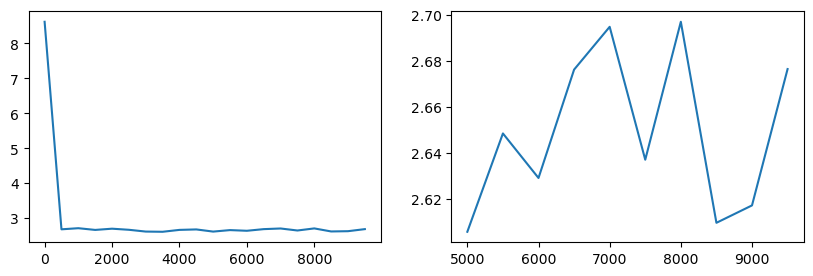

In [132]:
import matplotlib.pyplot as plt

last_n_step = 10
fig,ax = plt.subplots(1,2,figsize = (10,3))
ax[0].plot(np.arange(len(loss_list)) * step , loss_list)
ax[1].plot(range((len(loss_list)- last_n_step) * step , len(loss_list) * step , step) ,loss_list[-last_n_step:])
plt.show()

# Params

In [133]:
specials = {"q_mu": "Z.q_mu", "q_log_sigma": "Z.q_log_sigma"}
specials_val = {"q_mu": "Z_val.q_mu", "q_log_sigma": "Z_val.q_log_sigma"}

if model_name.endswith("_val"):
    specials = specials_val
params = [specials.get(s, s) for s in dict.fromkeys(k.rsplit('.', 1)[-1] for k in param_hist)]

params

['Z.q_mu', 'Z.q_log_sigma', 'raw_constant', 'raw_variance']

In [134]:
from utils.inspectors import plot_param_history

key = 'raw_constant'
fig = plot_param_history(param_hist = param_hist, key= key, ls_num=3, x_start= 0, x_step=config["logging"]["param_logging_freq"])
fig

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'raw_constant_0',
              'type': 'scatter',
              'uid': '0b5088c2-8c7b-4879-b94b-af42bc0df86d',
              'x': {'bdata': 'AAD0AegD3AXQB8QJuAusDaAPlBGIE3wVcBdkGVgbTB1AHzQhKCMcJQ==', 'dtype': 'i2'},
              'y': {'bdata': ('CNcjPIepNT6j+jc+p145PlafOT6pZi' ... 'o+qLI1PiZSQj7QSUc+UAw4PsVBNz4='),
                    'dtype': 'f4'}},
             {'mode': 'lines',
              'name': 'raw_constant_1',
              'type': 'scatter',
              'uid': 'fde51e9a-8e6f-4de4-8389-60694928eca7',
              'x': {'bdata': 'AAD0AegD3AXQB8QJuAusDaAPlBGIE3wVcBdkGVgbTB1AHzQhKCMcJQ==', 'dtype': 'i2'},
              'y': {'bdata': ('CdcjPLy4xT4vg9o+A7EJPzrqJT/y+D' ... 'g/WxBGP9zARz8DJ0k/z6BIP+vyQj8='),
                    'dtype': 'f4'}},
             {'mode': 'lines',
              'name': 'raw_constant_2',
              'type': 'scatter',
              'uid': '104d8620-2f43-488b-960a-5f71068c696d',
  

## Linear Weights 

In [135]:
weights = []
for t in range(config["T"]): 
    weights.append(param_hist[f"gps.{t}.mean_module.weights"][-1])
weights =np.array(weights).squeeze()

KeyError: 'gps.0.mean_module.weights'

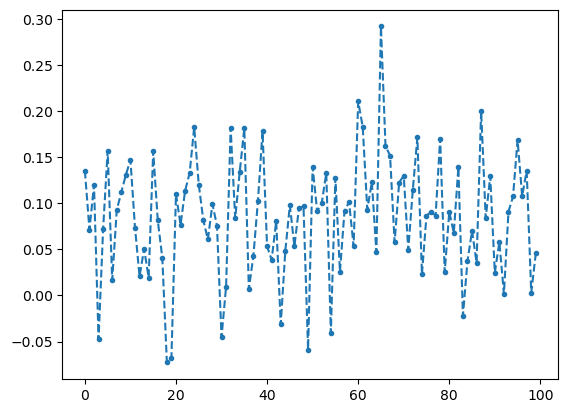

In [112]:
plt.plot(weights[:,3], "--.")

## Latent VS Real Dist

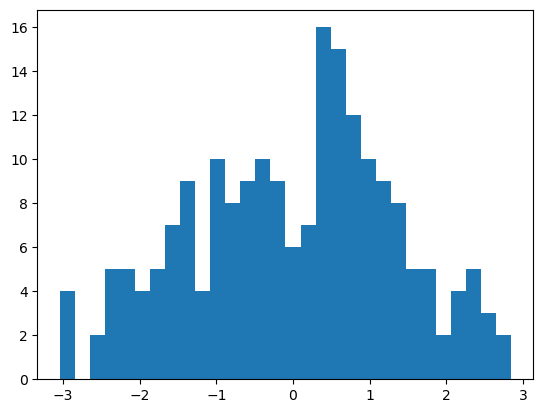

In [136]:
plt.hist(param_hist["Z.q_mu"][-1].squeeze(), bins=30)
plt.show()

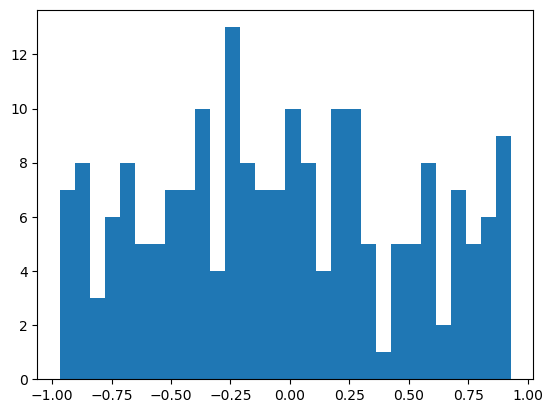

In [137]:
plt.hist(df[df.patient_id.isin(train_split)].drop_duplicates(subset=["patient_id"])["alpha"], bins=30)
plt.show()

## Correlation Between the Estimated Latent and The Real Variable 

In [138]:
id_col = "patient_id"  # or "patient_id"
uniq_ids = df[id_col].unique()
id2row = {pid: i for i, pid in enumerate(uniq_ids)}
train_ids_kept = [pid for pid in train_split if pid in id2row]     # X_train's row order
row_of = {pid: i for i, pid in enumerate(train_ids_kept)}         # pid -> row index in X_train

df_train = df[df[id_col].isin(train_ids_kept)].copy()
df_train["train_row"] = df_train[id_col].map(row_of)
df_train = df_train.sort_values(["train_row", "t"])          # now blocks match X_train rows


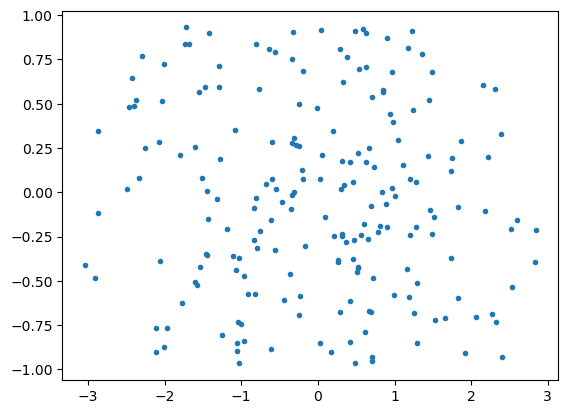

In [139]:
plt.plot(param_hist["Z.q_mu"][-1].squeeze(), df_train.drop_duplicates(subset=["patient_id"]).alpha.to_numpy(), ".")

In [140]:
np.corrcoef(param_hist["Z.q_mu"][-1].squeeze(), df_train.drop_duplicates(subset=["patient_id"]).alpha.to_numpy())

array([[ 1.        , -0.07220694],
       [-0.07220694,  1.        ]])

# Propensity Score 

In [141]:
from trainers.seqgplvm_propensity import propensity_seqgplvm 

propensity_seqgplvm(train_id= train_id, sample_count=100, load_data=False)

h:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM\utils\checkpoints.py:313: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Saved log–GPS tensor to: results\propensity\seqgplvm\309cbfc22e\loggps_309cbfc22e.pt  shape=(250, 4, 100)


In [142]:
import torch 
from utils.propensity import propensity_dir
path = propensity_dir(cwd/Path("./results").expanduser(), "seqgplvm", train_id)
payload = torch.load(path/f"loggps_{train_id}.pt", map_location="cpu")
propensity_score = payload["propensity"]

C:\Users\alise\AppData\Local\Temp\ipykernel_31296\4027611034.py:4: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



## PPC

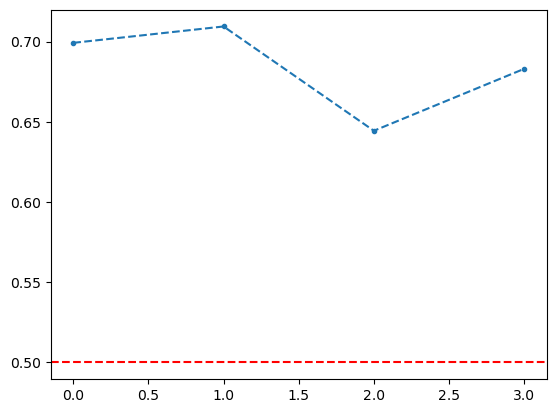

In [143]:
log_gps_z_meaned = payload["log_gps"][payload["index"]["pids_val"]].mean(dim = 2)
log_gps_samples_z_meaned = payload["log_gps_samples_z_meaned"][:,payload["index"]["pids_val"],:]
ppc = (log_gps_samples_z_meaned<log_gps_z_meaned).to(torch.float32).mean(dim=1).mean(dim = 0)
plt.plot(ppc, '.--')
plt.axhline(0.5, color='red', linestyle='--')
plt.show()

In [144]:
P, T, S = propensity_score.shape
arr = propensity_score.detach().cpu().numpy().reshape(P*T, S)

# id columns
patient_id = np.repeat(np.arange(P), T)
t = np.tile(np.arange(1,T+1), P)

# build dataframe
batch_cols = [f"phat_batch_{i+1}" for i in range(S)]
propensity_df = pd.DataFrame(arr, columns=batch_cols)
propensity_df.insert(0, "t", t)
propensity_df.insert(0, "patient_id", patient_id)

df_phat = df.merge(propensity_df,on=["patient_id", "t"], how="inner")

df_phat["phat_mean"] = df_phat[batch_cols].mean(axis=1)
df_phat["phat_std"] = df_phat[batch_cols].std(axis=1)

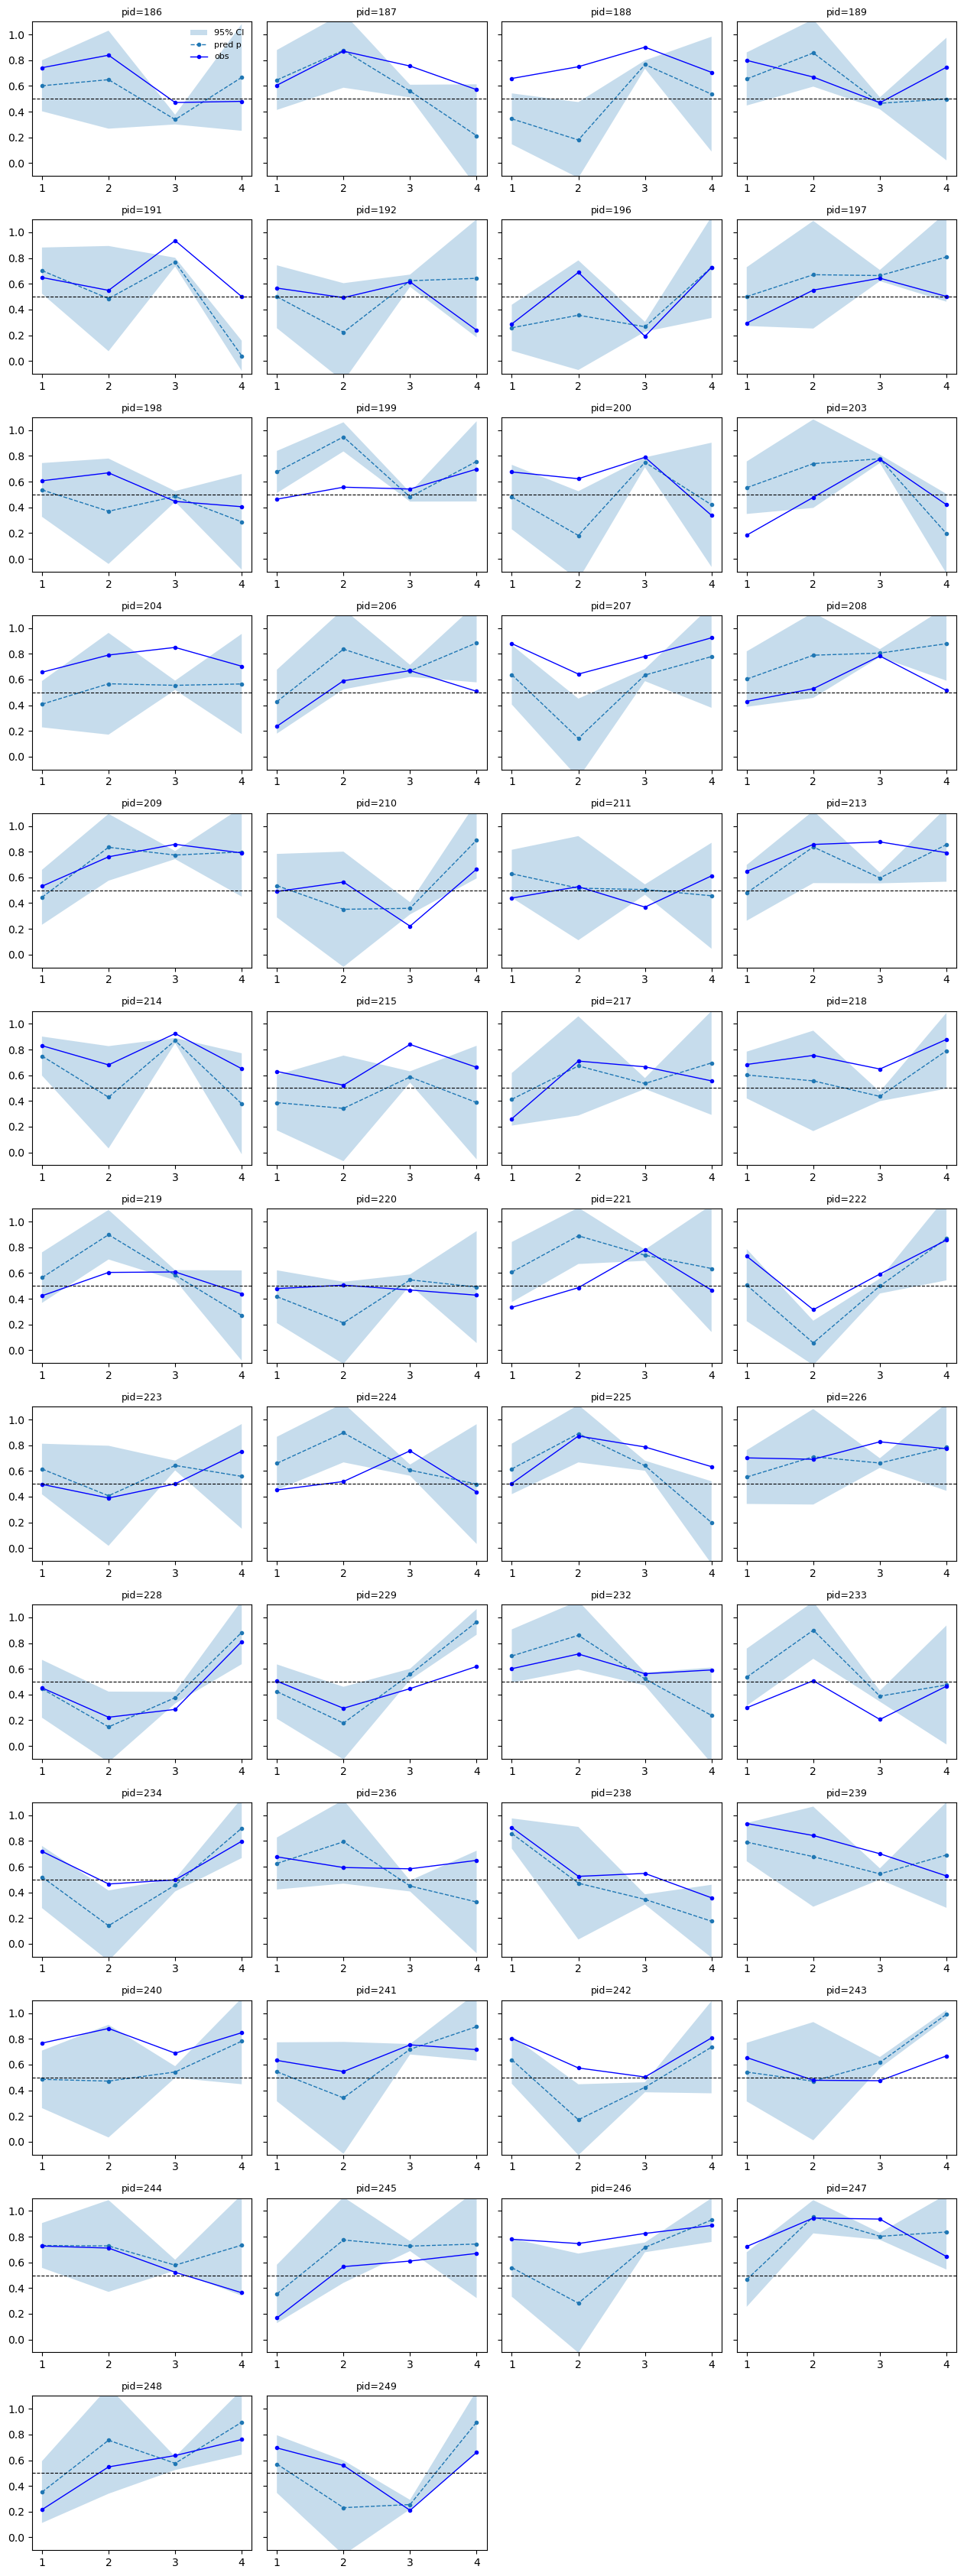

In [145]:
import numpy as np
import matplotlib.pyplot as plt

def plot_patient_grid(pids, df, ncols=4):
    """
    pids: list of patient_ids to show
    df: DataFrame with columns ['patient_id','t','D'] (or at least patient_id & D in order)
    ncols: number of columns in the grid
    """
    n = len(pids)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.6*nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, pid in zip(axes, pids):
        # get predicted traj
        t = df.loc[df.patient_id == pid, "t"].to_numpy()
        pred = df.loc[df.patient_id == pid, "phat_mean"].to_numpy()

        # get observed traj (assumes rows are in time order)
        obs = df.loc[df.patient_id == pid, "p_true"].to_numpy()



        # confidence band
        lo = df.loc[df.patient_id == pid, "phat_mean"] - 1.96 * df.loc[df.patient_id == pid, "phat_std"]
        hi = df.loc[df.patient_id == pid, "phat_mean"] + 1.96 * df.loc[df.patient_id == pid, "phat_std"]
        ax.fill_between(t, lo, hi, alpha=0.25, linewidth=0, label="95% CI")

        ax.plot(t,pred, "--.", lw=1, label="pred p")
        ax.plot(t,obs, ".-", c="blue", lw=1, label="obs")
        #ax.plot((pred >= 0.5).astype(int), ".-", c="orange", lw=1, label="pred 0/1")
        ax.axhline(0.5, color="k", ls="--", lw=0.8)
        ax.set_ylim(-0.1, 1.1)
        ax.set_title(f"pid={pid}", fontsize=9)

    # hide any unused panels
    for ax in axes[n:]:
        ax.axis("off")

    # one legend
    handles, labels = axes[0].get_legend_handles_labels()
    handles, labels = axes.flat[0].get_legend_handles_labels()
    axes.flat[0].legend(handles, labels, loc="upper right", frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()


pids_to_show = sorted(payload["index"]["pids_train"])  # pick any
plot_patient_grid(pids_to_show[-50:], df_phat, ncols=4)

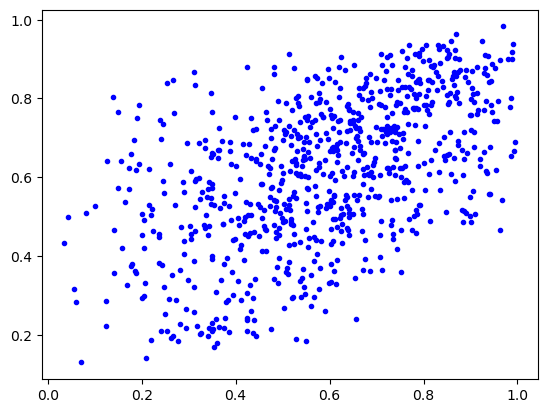

In [103]:
plt.plot(df_phat[df.patient_id.isin(train_split)]["phat_mean"],df_phat[df.patient_id.isin(train_split)]["p_true"],".", c="b", lw=1, label="pred p")
plt.show()

# MSM

## Fix Effect Method 

In [109]:
import statsmodels.api as sm

Exclude the only treated/not treated 

In [106]:
df_temp  = df.groupby('patient_id')['D'].agg(['min', 'max', 'mean'])
exclude_pids = []
if df_temp[df_temp["mean"]==1].shape[0] > 0 or df_temp[df_temp["mean"]==0].shape[0] > 0:
    only_treated_pids = df_temp[df_temp["mean"]==1].index.tolist()
    only_untreated_pids = df_temp[df_temp["mean"]==0].index.tolist()
    exclude_pids = only_treated_pids + only_untreated_pids

In [107]:
df[df.patient_id.isin(train_split) & ~df.patient_id.isin(exclude_pids)].copy().patient_id.nunique() 

200

In [110]:
X_list = [] 
df_fe = df[df.patient_id.isin(train_split) &  ~df.patient_id.isin(exclude_pids)].copy() 

X_list.append(pd.Series(1.0, index=df_fe.index, name="intercept")) 
X_list.append(df_fe[["lag1_D"]]) 
X_list.append(df_fe[df.columns[df.columns.str.startswith("x")].to_list()]) 
## First without fixed effects 
X = pd.concat(X_list, axis=1).astype(float) 
y = df_fe["D"].astype(int).values 

# GLM Binomial (logit) 
model = sm.GLM(y, X, family=sm.families.Binomial()) 
res = model.fit() 
df_fe["phat_no_fe"] = res.predict(X) 
fe = pd.get_dummies(df_fe["patient_id"].astype("category"), prefix="u", drop_first=True, dtype=float) 
X_list.append(fe) 
X = pd.concat(X_list, axis=1).astype(float) 
y = df_fe["D"].astype(int).values 
# GLM Binomial (logit) 
model = sm.GLM(y, X, family=sm.families.Binomial()) 
res = model.fit() 
df_fe["phat_fe"] = res.predict(X)

### Diagnostics 

#### Correlation Between the estimated fix effect and the true fix effects

In [111]:
fix_effects = []
id_fixeffects = {}
id_fixeffects[sorted(df_fe.patient_id.unique())[0]] = res.params["intercept"] # first person in the fe regression 
fix_effects.append(res.params["intercept"])
for item in res.params.index[res.params.index.str.startswith("u_")]:    
    fix_effects.append(res.params[item])
    id_fixeffects[int(item.split("_")[1])] = res.params[item]

np.corrcoef(fix_effects, df_fe.drop_duplicates(subset=["patient_id"]).sort_values(by="patient_id").alpha.to_numpy())

array([[1.        , 0.34485105],
       [0.34485105, 1.        ]])

In [112]:
extreme_ids = [k for k,v in id_fixeffects.items() if v>10 or v<-10]

Text(0, 0.5, 'Alpha values')

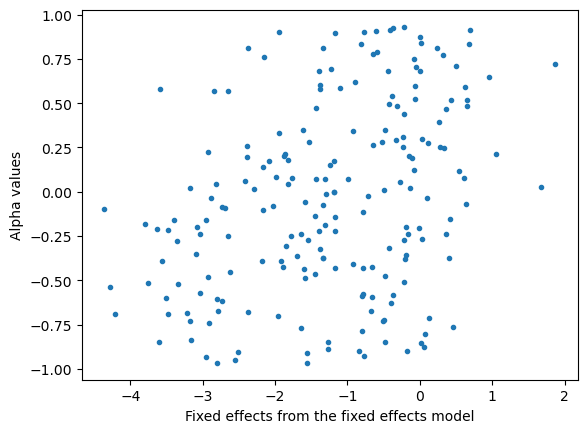

In [113]:
plt.plot(fix_effects, df_fe.drop_duplicates(subset=["patient_id"]).sort_values(by="patient_id").alpha.to_numpy(), ".")
plt.xlabel("Fixed effects from the fixed effects model")
plt.ylabel("Alpha values")

The extreme values correspond to individuals who are either always treated or always untreated. 

In [114]:
fe_dig = df_fe.groupby('patient_id')['D'].agg(['min', 'max', 'mean'])
fe_dig[fe_dig.index.isin(extreme_ids)]["mean"].value_counts()

Series([], Name: count, dtype: int64)

if we exclude those extremes: 

In [115]:
fe_without_extremes = [v for k,v in id_fixeffects.items() if k not in extreme_ids]
df_train_without_extremes = df_train.drop_duplicates(subset=["patient_id"]).loc[~df_train["patient_id"].isin(extreme_ids)]

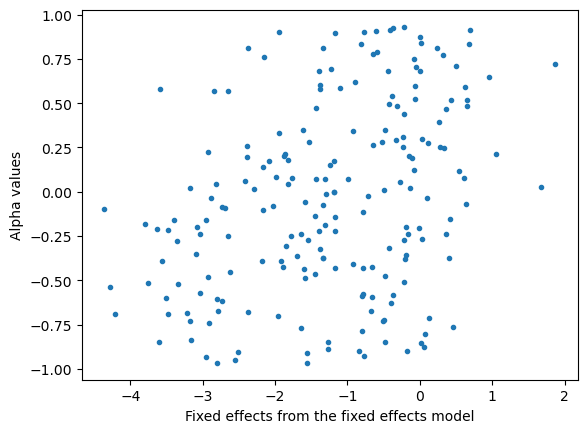

In [116]:
plt.plot([v for k,v in id_fixeffects.items() if k not in extreme_ids], df_train_without_extremes.sort_values(by="patient_id").alpha.to_numpy(), ".")
plt.xlabel("Fixed effects from the fixed effects model")
plt.ylabel("Alpha values")
plt.show()

In [117]:
np.corrcoef(fe_without_extremes, df_train_without_extremes.sort_values(by="patient_id").alpha.to_numpy())

array([[1.        , 0.34485105],
       [0.34485105, 1.        ]])

### Estimated Treatment Probability using FE VS True 

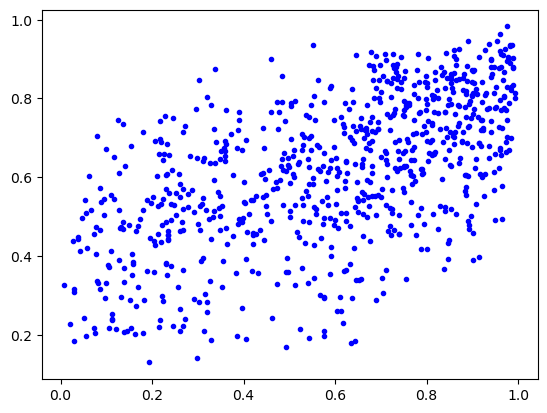

In [118]:
plt.plot(df_fe["phat_fe"], df_fe["p_true"],".", c="b", lw=1, label="pred p")
plt.show()

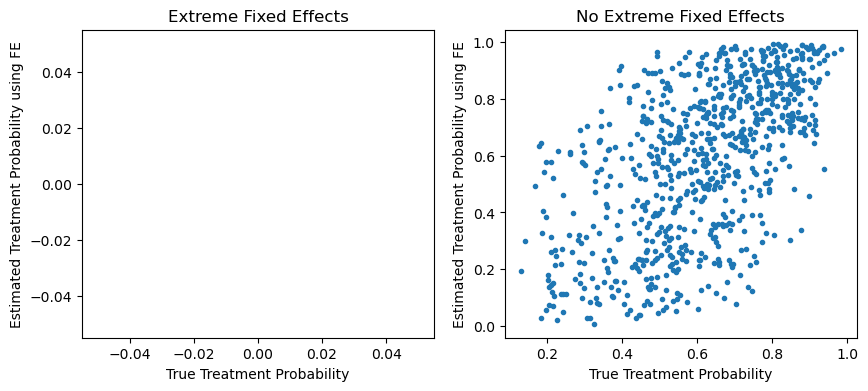

In [119]:
ptrue_phat_fe_extreme = df_fe.loc[df_fe["patient_id"].isin(extreme_ids)].sort_values(ascending=True,by="p_true")[["p_true", "phat_fe"]]
ptrue_phat_fe_no_extreme = df_fe.loc[~df_fe["patient_id"].isin(extreme_ids)].sort_values(ascending=True,by="p_true")[["p_true", "phat_fe"]]

fig,ax = plt.subplots(1,2,figsize = (10,4))
ax[0].plot(ptrue_phat_fe_extreme["p_true"], ptrue_phat_fe_extreme["phat_fe"], ".")
ax[1].plot(ptrue_phat_fe_no_extreme["p_true"], ptrue_phat_fe_no_extreme["phat_fe"], ".")
ax[0].set_title("Extreme Fixed Effects")
ax[1].set_title("No Extreme Fixed Effects")
ax[0].set_xlabel("True Treatment Probability")
ax[1].set_xlabel("True Treatment Probability")
ax[0].set_ylabel("Estimated Treatment Probability using FE")
ax[1].set_ylabel("Estimated Treatment Probability using FE")    
plt.show()

## Stabilizing Numerator 

In [120]:
X_list = []
X_list.append(pd.Series(1.0, index=df_fe.index, name="intercept"))
X_list.append(df_fe[["lag1_D"]])

X = pd.concat(X_list, axis=1).astype(float)
y = df_fe["D"].astype(int).values

# GLM Binomial (logit)
model = sm.GLM(y, X, family=sm.families.Binomial())
res = model.fit()

df_fe["stab_num"] = res.predict(X)

## Weights

In [124]:
df_phat

,patient_id,t,D,Y,alpha,eta_true,p_true,x0,x1,lag1_D,...,phat_batch_93,phat_batch_94,phat_batch_95,phat_batch_96,phat_batch_97,phat_batch_98,phat_batch_99,phat_batch_100,phat_mean,phat_std
0,0,1,1,NaN,0.023643,-0.668972,0.338727,0.301225,1.084005,0.0,...,0.365371,0.277894,0.337395,0.287242,0.243502,0.319604,0.170079,0.203635,0.298904,0.077903
1,0,2,0,NaN,0.023643,0.548813,0.633860,-0.430628,-0.019711,1.0,...,0.394314,0.201266,0.328615,0.219722,0.139737,0.288357,0.047397,0.082678,0.261151,0.155142
2,0,3,1,NaN,0.023643,0.260584,0.564780,-0.199157,-0.274724,0.0,...,0.583243,0.601973,0.589052,0.599879,0.609950,0.592824,0.629082,0.619893,0.598186,0.017561
3,0,4,1,2.000643,0.023643,1.014018,0.733806,-0.218150,-1.162600,1.0,...,0.660432,0.842178,0.724276,0.825645,0.895616,0.762453,0.969092,0.942262,0.781541,0.146244
4,1,1,1,NaN,0.900927,1.926677,0.872881,-0.728559,-1.322940,0.0,...,0.583076,0.655540,0.705388,0.644744,0.545954,0.577712,0.601445,0.721352,0.632223,0.112827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,248,4,1,-0.084859,-0.306135,1.160246,0.761377,-1.998784,-0.933978,0.0,...,0.994511,0.866505,0.976784,0.992487,0.942907,0.831948,0.941401,0.974507,0.914835,0.109958
996,249,1,1,NaN,0.171707,0.827334,0.695791,-0.516142,-0.795113,0.0,...,0.615707,0.696250,0.708366,0.618851,0.633188,0.622162,0.621001,0.626481,0.579165,0.117120
997,249,2,0,NaN,0.171707,0.240063,0.559729,0.105720,0.357567,1.0,...,0.257886,0.442506,0.474688,0.264005,0.293088,0.270551,0.268245,0.279243,0.246915,0.174006
998,249,3,0,NaN,0.171707,-1.322995,0.210320,0.883799,2.105605,0.0,...,0.247777,0.235108,0.233166,0.247286,0.245045,0.246769,0.246950,0.246094,0.253948,0.019496


In [ ]:
T = config['T']

df_msm = df_phat.loc[(df_phat['t'] >= T-3) & (df_phat['t'] <= T), ['patient_id', 't', 'D',"lag_sum"]  + ["Y",'p_true'] + batch_cols ]
df_msm = df_msm[df_msm['patient_id'].isin(train_split)]
df_msm = df_msm[~df_msm['patient_id'].isin(exclude_pids)]

df_fe = df_fe.loc[(df_fe['t'] >= T-3) & (df_fe['t'] <= T), ['patient_id', 't', 'D', "phat_fe", "phat_no_fe"]]

weights = (1 / df_msm[batch_cols]).where(df_msm['D'].eq(1), other=1 / (1 - df_msm[batch_cols]))
true_weights = (1 / df_msm["p_true"]).where(df_msm['D'].eq(1), other=1 / (1 - df_msm["p_true"]))
fe_weights = (1 / df_fe["phat_fe"]).where(df_fe['D'].eq(1), other=1 / (1 - df_fe["phat_fe"]))
no_fe_weights = (1 / df_fe["phat_no_fe"]).where(df_fe['D'].eq(1), other=1 / (1 - df_fe["phat_no_fe"]))


# Time-varying cumulative IPTW per row (within patient)
# Useful for MSM trajectory weighting or diagnostics per time step
weights_cum = weights.groupby(df_msm['patient_id'])[batch_cols].cumprod()
weights_cum.columns = [f'ipw_cum_{c}' for c in batch_cols]

weights_cum["ipw_cum_true"] = true_weights.groupby(df_msm['patient_id']).cumprod()
weights_cum["ipw_cum_fe"] = fe_weights.groupby(df_fe['patient_id']).cumprod()
weights_cum["ipw_cum_no_fe"] = no_fe_weights.groupby(df_fe['patient_id']).cumprod()

# Attach to a compact DataFrame (patient_id, t, ipw_cum_*); keep df_msm unchanged
df_msm_ipw = pd.concat([df_msm[['patient_id','t']], weights_cum], axis=1)
df_msm = df_msm.merge(df_msm_ipw, on=['patient_id', 't'], how='left')

In [126]:
df_msm_reg = df_msm[df_msm['t'] == T]
y = df_msm_reg['Y']
X = df_msm_reg[['D', 'lag_sum']]
X = sm.add_constant(X)
tau_f = []
tau_c = []
for i,batch in enumerate(weights_cum.columns):
    model = sm.WLS(y, X, weights=df_msm_reg[batch])
    res = model.fit()
    tau_f.append(res.params.D)
    tau_c.append(res.params.lag_sum)

model = sm.WLS(y, X, weights=df_msm_reg["ipw_cum_true"])
res = model.fit()

tau_f_true = res.params.D
tau_c_true = res.params.lag_sum

# With fixed effects
model = sm.WLS(y, X, weights=df_msm_reg["ipw_cum_fe"])
res = model.fit()
tau_f_fe = res.params.D
tau_c_fe = res.params.lag_sum
# Without fixed effects
model = sm.WLS(y, X, weights=df_msm_reg["ipw_cum_no_fe"])
res = model.fit()
tau_f_no_fe = res.params.D
tau_c_no_fe = res.params.lag_sum

KeyError: "['lag_sum'] not in index"

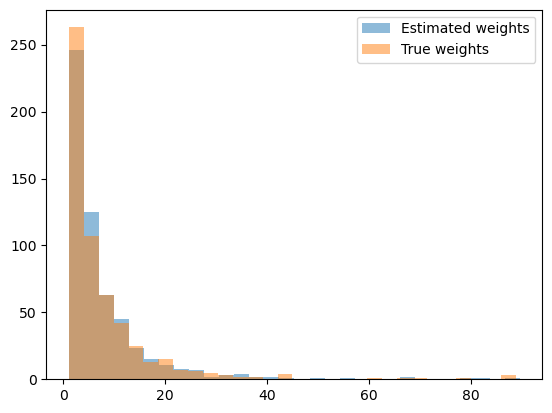

In [226]:
plt.hist(df_msm.filter(regex=r"^ipw_cum_phat_batch").mean(axis=1), bins=30, alpha=0.5, label='Estimated weights')
plt.hist(df_msm["ipw_cum_true"], bins=30, alpha=0.5, label='True weights')
plt.legend()
plt.show()

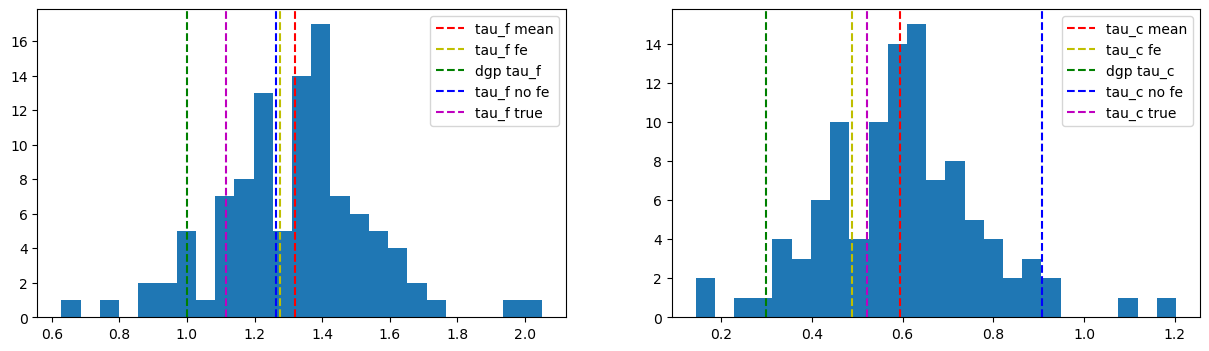

In [229]:
fig,ax = plt.subplots(1,2,figsize = (15,4))
ax[0].hist(np.array(tau_f), bins=25)
ax[0].axvline(x=np.mean(tau_f), color='r', linestyle='--', label='tau_f mean')
ax[0].axvline(x=np.mean(tau_f_fe), color='y', linestyle='--', label='tau_f fe')
ax[0].axvline(x=df_manifest["params"]["tau_F"], color='g', linestyle='--', label='dgp tau_f')
ax[0].axvline(x=np.mean(tau_f_no_fe), color='b', linestyle='--', label='tau_f no fe')
ax[0].axvline(x=np.mean(tau_f_true), color='m', linestyle='--', label='tau_f true')


ax[1].hist(np.array(tau_c), bins=25)
ax[1].axvline(x=np.mean(tau_c), color='r', linestyle='--', label='tau_c mean')
ax[1].axvline(x=np.mean(tau_c_fe), color='y', linestyle='--', label='tau_c fe')
ax[1].axvline(x=df_manifest["params"]["tau_C"], color='g', linestyle='--', label='dgp tau_c')
ax[1].axvline(x=np.mean(tau_c_no_fe), color='b', linestyle='--', label='tau_c no fe')
ax[1].axvline(x=np.mean(tau_c_true), color='m', linestyle='--', label='tau_c true')
ax[0].legend()
ax[1].legend()
plt.show()

<Axes: >

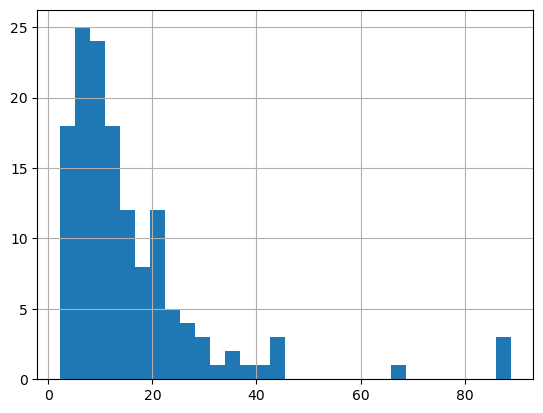

In [228]:
df_msm_reg["ipw_cum_true"].hist(bins=30)

In [ ]:
from pathlib import Path

path = cwd/"data"/"raw"/"blackwell_yamauchi"

folders = [f.name for f in path.iterdir() if f.is_dir()]

for data_id_folder in folders:
    # Load data
    df_path = path/data_id_folder/"data.parquet"
    df_manifest_path = path/data_id_folder/"manifest.json"
    df_manifest = json.loads((df_manifest_path).read_text(encoding="utf-8"))
    df = pd.read_parquet(df_path)
    # Exclude always-treated or never-treated patients
    df_temp  = df.groupby('patient_id')['D'].agg(['min', 'max', 'mean'])
    if df_temp[df_temp["mean"]==1].shape[0] > 0 or df_temp[df_temp["mean"]==0].shape[0] > 0:
        only_treated_pids = df_temp[df_temp["mean"]==1].index.tolist()
        only_untreated_pids = df_temp[df_temp["mean"]==0].index.tolist()
    exclude_pids = only_treated_pids + only_untreated_pids

    X_list = [] 
    df_fe = df[df.patient_id.isin(train_split) &  ~df.patient_id.isin(exclude_pids)].copy() 
    df_fe = df_fe.sort_values(by=["patient_id", "t"])
    df_fe["lag3_sum_D"] = df_fe[["lag1_D","lag2_D","lag3_D"]].sum(axis=1)

    X_list.append(pd.Series(1.0, index=df_fe.index, name="intercept")) 
    X_list.append(df_fe[["lag1_D"]]) 
    X_list.append(df_fe[df.columns[df.columns.str.startswith("x")].to_list()]) 
    ## First without fixed effects 
    X = pd.concat(X_list, axis=1).astype(float) 
    y = df_fe["D"].astype(int).values 

    model = sm.GLM(y, X, family=sm.families.Binomial()) 
    res = model.fit() 
    df_fe["phat_no_fe"] = res.predict(X) 
    ## Now with fixed effects
    fe = pd.get_dummies(df_fe["patient_id"].astype("category"), prefix="u", drop_first=True, dtype=float) 
    X_list.append(fe) 
    X = pd.concat(X_list, axis=1).astype(float) 
    y = df_fe["D"].astype(int).values 
    model = sm.GLM(y, X, family=sm.families.Binomial()) 
    res = model.fit() 
    df_fe["phat_fe"] = res.predict(X)
    ## Calculate cumulative IPW weights for last 4 time points
    T = df_manifest['params']['T']

    true_weights = (1 / df_fe["p_true"]).where(df_fe['D'].eq(1), other=1 / (1 - df_fe["p_true"]))
    fe_weights = (1 / df_fe["phat_fe"]).where(df_fe['D'].eq(1), other=1 / (1 - df_fe["phat_fe"]))
    no_fe_weights = (1 / df_fe["phat_no_fe"]).where(df_fe['D'].eq(1), other=1 / (1 - df_fe["phat_no_fe"]))

    mask_last4 = df_fe["t"].between(T-3, T)

    df_fe["ipw_cum_true"] = true_weights.groupby(df_fe['patient_id']).cumprod()
    df_fe["ipw_cum_fe"] = fe_weights.groupby(df_fe['patient_id']).cumprod()
    df_fe["ipw_cum_no_fe"] = no_fe_weights.groupby(df_fe['patient_id']).cumprod()
    # MSM regression at final time point
    df_msm_reg = df_fe[df_fe['t'] == T]
    y = df_msm_reg['Y']
    X = df_msm_reg[['D', 'lag3_sum_D']]
    X = sm.add_constant(X)

    # True weights
    model = sm.WLS(y, X, weights=df_msm_reg["ipw_cum_true"])
    res = model.fit()
    tau_f_true = res.params.D
    tau_c_true = res.params.lag3_sum_D

    # With fixed effects
    model = sm.WLS(y, X, weights=df_msm_reg["ipw_cum_fe"])
    res = model.fit()
    tau_f_fe = res.params.D
    tau_c_fe = res.params.lag3_sum_D
    # Without fixed effects
    model = sm.WLS(y, X, weights=df_msm_reg["ipw_cum_no_fe"])
    res = model.fit()
    tau_f_no_fe = res.params.D
    tau_c_no_fe = res.params.lag3_sum_D
    
    break

In [338]:
len(json.loads((cwd/df_manifest["split_file"]).read_text(encoding="utf-8"))["train_ids"])

200

In [ ]:
from pathlib import Path
import statsmodels.api as sm
import pandas as pd

path = cwd/"data"/"raw"/"blackwell_yamauchi"

folders = [f.name for f in path.iterdir() if f.is_dir()]

df_results = pd.DataFrame(columns=["data_id", "N", "T", "rho", "tau_f_true", "tau_c_true", "tau_f_fe", "tau_c_fe", "tau_f_no_fe", "tau_c_no_fe"])
for num,data_id_folder in enumerate(folders):
    print(f"Processing data folder: {num}/{len(folders)}: {data_id_folder}", end="\r")
    # Load data
    df_path = path/data_id_folder/"data.parquet"
    df_manifest_path = path/data_id_folder/"manifest.json"
    df_manifest = json.loads((df_manifest_path).read_text(encoding="utf-8"))
    df = pd.read_parquet(df_path)

    splits  = json.loads((cwd/Path(df_manifest["split_file"])).read_text(encoding="utf-8"))
    train_split = splits["train_ids"]
    N = len(train_split)

    T = df_manifest['params']['T'] 
    rho = int(N/T)
    # Exclude always-treated or never-treated patients
    df_temp  = df.groupby('patient_id')['D'].agg(['min', 'max', 'mean'])

    exclude_pids = []
    if df_temp[df_temp["mean"]==1].shape[0] > 0 or df_temp[df_temp["mean"]==0].shape[0] > 0:
        only_treated_pids = df_temp[df_temp["mean"]==1].index.tolist()
        only_untreated_pids = df_temp[df_temp["mean"]==0].index.tolist()
        exclude_pids = only_treated_pids + only_untreated_pids

    # --- prep
    df_fe = df[~df.patient_id.isin(exclude_pids) & df.patient_id.isin(train_split)].copy()
    df_fe = df_fe.sort_values(["patient_id","t"])
    T_final = df_fe["t"].max()
    mask_last4 = df_fe["t"].between(T_final-3, T_final)

    # MSM regressors at final time
    df_fe["lag_sum3"] = df_fe[["lag1_D","lag2_D","lag3_D"]].sum(axis=1)
    df_msm = df_fe[df_fe["t"]==T_final]
    X_msm = sm.add_constant(df_msm[["D","lag_sum3"]]); y_msm = df_msm["Y"]

    # --- propensity models
    # numerator: stabilized, D_t ~ D_{t-1}
    num_X = sm.add_constant(df_fe[["lag1_D"]])
    num_mod = sm.GLM(df_fe["D"], num_X, family=sm.families.Binomial()).fit()
    p_num = num_mod.predict(num_X).clip(1e-6, 1-1e-6)

    # denominator no-FE: D_t ~ D_{t-1}, X_t
    den_X_no = sm.add_constant(pd.concat([df_fe[["lag1_D"]],
                                        df_fe.filter(regex=r"^x")], axis=1))
    den_no = sm.GLM(df_fe["D"], den_X_no, family=sm.families.Binomial()).fit()
    p_no = den_no.predict(den_X_no).clip(1e-6, 1-1e-6)

    # denominator FE: add unit fixed effects
    fe = pd.get_dummies(df_fe["patient_id"].astype("category"), drop_first=True, dtype=float)
    den_X_fe = pd.concat([den_X_no, fe], axis=1)
    den_fe = sm.GLM(df_fe["D"], den_X_fe, family=sm.families.Binomial()).fit()
    p_fe = den_fe.predict(den_X_fe).clip(1e-6, 1-1e-6)

    # (optional) true p from generator if available
    p_true = df_fe["p_true"].clip(1e-6, 1-1e-6)

    # per-period stabilized weights
    def per_period_w(p_num, p_den, D):
        return np.where(D==1, p_num/p_den, (1-p_num)/(1-p_den))

    w_true_it = per_period_w(p_num, p_true.values, df_fe["D"].values)
    w_fe_it   = per_period_w(p_num, p_fe.values,   df_fe["D"].values)
    w_no_it   = per_period_w(p_num, p_no.values,   df_fe["D"].values)

    # product over the last 4 periods only, then keep at t==T
    def last4_prod(w_it):
        tmp = df_fe.loc[mask_last4, ["patient_id"]].copy()
        tmp["w"] = w_it[mask_last4.values]
        return tmp.groupby("patient_id")["w"].prod()

    W_true = last4_prod(w_true_it)
    W_fe   = last4_prod(w_fe_it)
    W_no   = last4_prod(w_no_it)

    # align weights with final-time rows
    w_true = df_msm["patient_id"].map(W_true)
    w_fe   = df_msm["patient_id"].map(W_fe)
    w_no   = df_msm["patient_id"].map(W_no)

    # --- weighted MSM fits
    def fit_wls(w):
        return sm.WLS(y_msm, X_msm, weights=w).fit(cov_type="HC2")

    res_true = fit_wls(w_true); tau_f_true = res_true.params["D"];      tau_c_true = res_true.params["lag_sum3"]
    res_fe   = fit_wls(w_fe);   tau_f_fe   = res_fe.params["D"];        tau_c_fe   = res_fe.params["lag_sum3"]
    res_no   = fit_wls(w_no);   tau_f_no   = res_no.params["D"];        tau_c_no   = res_no.params["lag_sum3"]
    # --- store results
    row = pd.DataFrame([{
    "data_id": df_manifest["run_id"],
    "N": N, "T": T, "rho": rho, "a": df_manifest['params']['a'], "p": df_manifest['params']['p'],
    "tau_f_true": tau_f_true, "tau_c_true": tau_c_true,
    "tau_f_fe": tau_f_fe, "tau_c_fe": tau_c_fe,
    "tau_f_no_fe": tau_f_no, "tau_c_no_fe": tau_c_no
    }])

    df_results = pd.concat([df_results, row], ignore_index=True)

C:\Users\alise\AppData\Local\Temp\ipykernel_51476\3672380870.py:101: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, row], ignore_index=True)


MemoryError: Unable to allocate 2.34 GiB for an array with shape (1255, 250000) and data type float64

In [15]:
df_fe

,patient_id,t,D,Y,alpha,eta_true,p_true,x0,x1,x2,x3,lag1_D,lag2_D,lag3_D,lag_sum3
0,0,1,1,NaN,0.023643,1.375629,0.798288,-1.028721,-1.812468,-1.006792,-1.876365,0.0,0.0,0.0,0.0
1,0,2,0,NaN,0.023643,-2.567828,0.071238,-0.450571,-0.250849,-2.936304,0.611754,1.0,0.0,0.0,1.0
2,0,3,1,NaN,0.023643,2.091258,0.890051,0.513519,-0.687899,1.701391,-0.558066,0.0,1.0,0.0,1.0
3,0,4,0,NaN,0.023643,0.002717,0.500679,-0.542878,0.265906,-1.507630,-2.096437,1.0,0.0,1.0,2.0
4,0,5,0,NaN,0.023643,-0.238636,0.440622,-0.786249,0.422131,-0.017160,0.854357,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,1249,196,0,NaN,-0.942987,-1.356745,0.204770,-1.237932,0.518334,-1.075708,-0.604302,0.0,0.0,0.0,0.0
249996,1249,197,1,NaN,-0.942987,0.372371,0.592032,-0.430274,-2.628975,-0.686050,-0.943569,0.0,0.0,0.0,0.0
249997,1249,198,1,NaN,-0.942987,-1.092011,0.251240,-1.653114,-1.138360,-2.423382,-1.157243,1.0,0.0,0.0,1.0
249998,1249,199,0,NaN,-0.942987,-1.316142,0.211461,0.254615,0.302877,-0.315541,0.157736,1.0,1.0,0.0,2.0


In [14]:
fe = pd.get_dummies(df_fe["patient_id"].astype("category"), drop_first=True, dtype=float)
fe.shape  # <-- this will show ~250,000 columns if that's the issue

(250000, 1249)

In [12]:
df_manifest

{'dgp': 'blackwell_yamauchi',
 'run_id': '61c0a3e1',
 'created_at': '2025-10-21T13:23:09Z',
 'path': 'data\\raw\\blackwell_yamauchi\\61c0a3e1',
 'git_commit': '067b684',
 'python': '3.12.3',
 'node': 'Ali-Setareh',
 'params': {'dgp': 'blackwell_yamauchi',
  'n': 1250,
  'T': 200,
  'seed': 1,
  'a': 1,
  'p': 4,
  'beta': [-0.5, -0.5, 1.0, -0.5],
  'gamma': [1.0, 0.5, 1.0, 1.0],
  'phi': 0.3,
  'tau_F': 1.0,
  'tau_C': 0.3,
  'mean_x': -0.5,
  'offdiag': 0.2,
  'sigma_eps': 1.0,
  'max_lag_x': 0,
  'max_lag_d': 3,
  'split_seed': 42,
  'treatment_model': 'logit'},
 'script': 'experiments/run_simulation.py',
 'split_file': 'data\\splits\\blackwell_yamauchi\\N1250_T200_p4_splitseed42.json',
 'split_info': {'by': 'unit', 'split_seed': 42}}

In [356]:
df_manifest["run_id"]

'b6f488a5'

In [346]:
pd.DataFrame({
        "data_id": df_manifest["run_id"],
        "N": N,
        "T": T,
        "rho": rho,
        "tau_f_true": tau_f_true,
        "tau_c_true": tau_c_true,
        "tau_f_fe": tau_f_fe,
        "tau_c_fe": tau_c_fe,
        "tau_f_no_fe": tau_f_no_fe,
        "tau_c_no_fe": tau_c_no_fe
    })

ValueError: If using all scalar values, you must pass an index

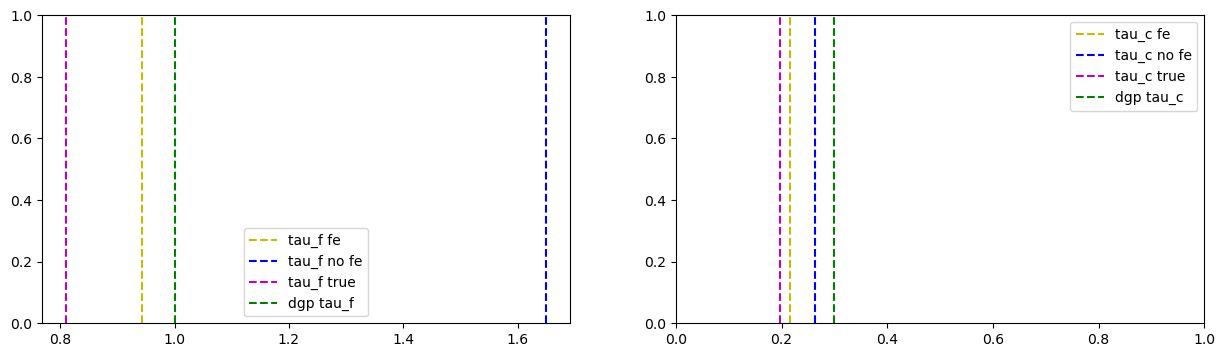

In [316]:
fig,ax = plt.subplots(1,2,figsize = (15,4))

ax[0].axvline(x=np.mean(tau_f_fe), color='y', linestyle='--', label='tau_f fe')
ax[0].axvline(x=np.mean(tau_f_no_fe), color='b', linestyle='--', label='tau_f no fe')
ax[0].axvline(x=np.mean(tau_f_true), color='m', linestyle='--', label='tau_f true')
ax[0].axvline(x=df_manifest["params"]["tau_F"], color='g', linestyle='--', label='dgp tau_f')

ax[1].axvline(x=np.mean(tau_c_fe), color='y', linestyle='--', label='tau_c fe')
ax[1].axvline(x=np.mean(tau_c_no_fe), color='b', linestyle='--', label='tau_c no fe')
ax[1].axvline(x=np.mean(tau_c_true), color='m', linestyle='--', label='tau_c true')
ax[1].axvline(x=df_manifest["params"]["tau_C"], color='g', linestyle='--', label='dgp tau_c')
ax[0].legend()
ax[1].legend()
plt.show()

In [320]:
print(f"tau_f dgp: {df_manifest['params']['tau_F']}, tau_c dgp: {df_manifest['params']['tau_C']}")
print(f"tau_f_true: {tau_f_true}, tau_c_true: {tau_c_true}, bias_f_true: {abs(tau_f_true - df_manifest['params']['tau_F'])}, bias_c_true: {abs(tau_c_true - df_manifest['params']['tau_C'])}")
print(f"tau_f_fe: {tau_f_fe}, tau_c_fe: {tau_c_fe}, bias_f_fe: {abs(tau_f_fe - df_manifest['params']['tau_F'])}, bias_c_fe: {abs(tau_c_fe - df_manifest['params']['tau_C'])}")
print(f"tau_f_no_fe: {tau_f_no_fe}, tau_c_no_fe: {tau_c_no_fe}, bias_f_no_fe: {abs(tau_f_no_fe - df_manifest['params']['tau_F'])}, bias_c_no_fe: {abs(tau_c_no_fe - df_manifest['params']['tau_C'])}")

tau_f dgp: 1.0, tau_c dgp: 0.3
tau_f_true: 0.8098295951148051, tau_c_true: 0.19782587644258143, bias_f_true: 0.19017040488519488, bias_c_true: 0.10217412355741856
tau_f_fe: 0.9431262151899726, tau_c_fe: 0.2158069582195799, bias_f_fe: 0.05687378481002736, bias_c_fe: 0.08419304178042009
tau_f_no_fe: 1.6499560462227858, tau_c_no_fe: 0.2636248745747002, bias_f_no_fe: 0.6499560462227858, bias_c_no_fe: 0.036375125425299804
